# **Part 3A: Neural Network [40 marks]**

In this part, you will implement a neural network and test its path prediction performance on the same dataset using PyTorch.

### Imports

In [1]:

import torch
import torch.nn as nn
# make other necessary imports here
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import os
import gym
import time
from collections import deque
from torch.distributions import Categorical
from torch.utils.tensorboard import SummaryWriter
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import matplotlib


### Processing Dataset

For this task, you will need to consider three different scenarios so you will need to process data three times.
- Predict the movement of the robot for the next 3 seconds i.e., 90 datapoints (x, y) at once based on previous:

    * 3 seconds i.e., 90 previous datapoints.
    * 6 seconds i.e., 180 previous datapoints.
    * 9 seconds i.e., 270 previous datapoints.

In [2]:
file_path = './Dataset/Training/training_data.txt'
# Do not edit this cell
def process_data(file_name):
    with open(file_name, 'r') as file:
        lines = file.readlines()
    data = []
    for line in lines:          # process the lines to extract x and y coordinates
        x_str, y_str = line.strip().split(',')
        x = int(x_str)
        y = int(y_str)
        data.append([x, y])     # store x and y coordinates for each time step
    data = np.array(data)
    return data

data=process_data(file_path)



 ### Model Architecture

In [3]:
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_shape,output_shape):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_shape, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_shape)
        self.relu = nn.ReLU()

    def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            x = self.fc3(x)
            return x  


You will use [Adam](https://pytorch.org/docs/stable/optim.html) optimizer and RMSE function from Part 1A for calculating neural network loss during the training of model. Visit the embedded link to know more about the training.

In [4]:
import torch

def loss_temp(output, target):
    return torch.sum((output - target) ** 2)

epochs = 170

def train_model(model, data, optimizer, learning_rate):
  
  optimizer = optimizer(model.parameters(), lr=learning_rate)
  model_rmse_epcoh = {}
  for epoch in range(epochs):
      total_data_points = 0
      loss = 0
      optimizer.zero_grad()
      for i in range(0, len(data)-batch_size, batch_size):
          x = torch.tensor(data[i:i+batch_size, :], dtype=torch.float32)
          y = torch.tensor(data[i+batch_size:i+batch_size+batch_size, :], dtype=torch.float32)[:90]
          output = model(x)  
          output = output[:90]  
          loss += loss_temp(output, y)
          total_data_points += batch_size
      loss = torch.sqrt(loss/total_data_points)
      model_rmse_epcoh[epoch] = loss
      loss.backward()
      optimizer.step()
      print(f'Epoch {epoch+1}, Loss: {loss}')
  return model_rmse_epcoh

batch_size = 90
model = NeuralNet(2,2)
optimizer = torch.optim.Adam 
model_1_rmse_epcoh = train_model(model, data, optimizer, learning_rate=0.0002)
batch_size = 180
model_180 = NeuralNet(2,2)
model_2_rmse_epcoh = train_model(model_180, data, optimizer, learning_rate=0.0002)
batch_size = 270
model_270 = NeuralNet(2,2)
model_3_rmse_epcoh = train_model(model_270, data, optimizer, learning_rate=0.0002)


Epoch 1, Loss: 446.39752197265625
Epoch 2, Loss: 440.0958557128906
Epoch 3, Loss: 433.810791015625
Epoch 4, Loss: 427.5660705566406
Epoch 5, Loss: 421.3752746582031
Epoch 6, Loss: 415.2541198730469
Epoch 7, Loss: 409.21002197265625
Epoch 8, Loss: 403.2420654296875
Epoch 9, Loss: 397.335693359375
Epoch 10, Loss: 391.5021667480469
Epoch 11, Loss: 385.7486572265625
Epoch 12, Loss: 380.0771484375
Epoch 13, Loss: 374.49798583984375
Epoch 14, Loss: 369.0043640136719
Epoch 15, Loss: 363.59722900390625
Epoch 16, Loss: 358.2810363769531
Epoch 17, Loss: 353.0572509765625
Epoch 18, Loss: 347.9302673339844
Epoch 19, Loss: 342.90191650390625
Epoch 20, Loss: 337.95660400390625
Epoch 21, Loss: 333.0902404785156
Epoch 22, Loss: 328.3094787597656
Epoch 23, Loss: 323.63763427734375
Epoch 24, Loss: 319.0693359375
Epoch 25, Loss: 314.60546875
Epoch 26, Loss: 310.25274658203125
Epoch 27, Loss: 306.0287780761719
Epoch 28, Loss: 301.9219970703125
Epoch 29, Loss: 297.92462158203125
Epoch 30, Loss: 294.0372009

### Evaluation and Analysis

*  Plot a line graph to evaluate your model's performance (using code for RMSE from Part 1A) across the lookback size range `i.e., 90 (3 sec), 180 (6 sec), 270 (9 sec)`. Identify and explain any trend in how the RMSE values change with varying lookback size.

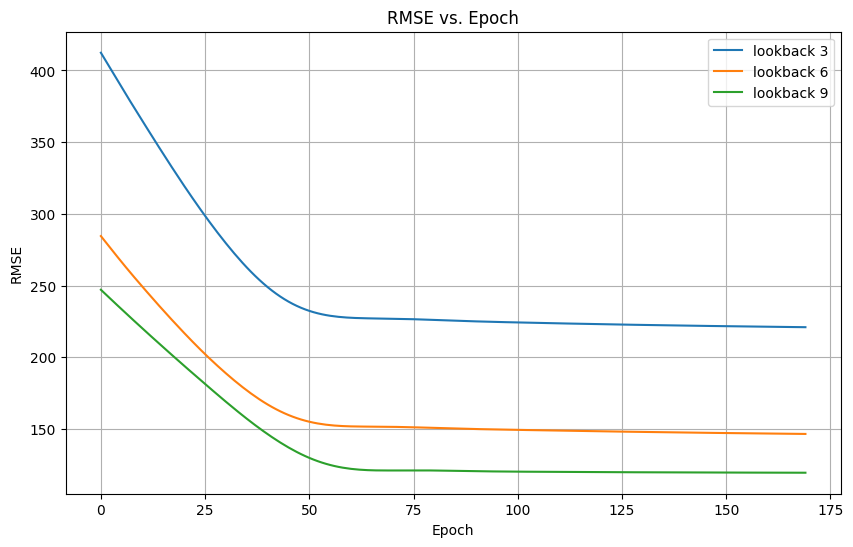

In [200]:
import matplotlib.pyplot as plt
model_1_rmse_epcoh_float = {epoch: value.item() for epoch, value in model_1_rmse_epcoh.items()}
model_2_rmse_epcoh_float = {epoch: value.item() for epoch, value in model_2_rmse_epcoh.items()}
model_3_rmse_epcoh_float = {epoch: value.item() for epoch, value in model_3_rmse_epcoh.items()}
plt.figure(figsize=(10, 6))
plt.plot(model_1_rmse_epcoh_float.keys(), model_1_rmse_epcoh_float.values(), label='lookback 3')
plt.plot(model_2_rmse_epcoh_float.keys(), model_2_rmse_epcoh_float.values(), label='lookback 6')
plt.plot(model_3_rmse_epcoh_float.keys(), model_3_rmse_epcoh_float.values(), label='lookback 9')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('RMSE vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()




### Double click to $\color{green}{\text{add explanation/reasoning here}}$
As lookback increases the rmse values decrease more rapidly. Moreover the final rmse values are also lower for the higher lookback values. This is because by increasing the lookback from 3 to 6 to 9 seconds, we are providing the neural network with more past movements of the robot. This additional information allows the network to capture more complex temporal patterns in the robot's behavior. For example, the robot might exhibit certain movement patterns or behaviors that span longer periods, and a larger lookback enables the network to learn and model these patterns more effectively.

### Visualization of Actual and Predicted Path

* Modify and use same code from the previous parts. The time interval should be 6 seconds (choose from wherever in the testing data). Note that this time your model predicts 3 seconds. Think about how to deal with this.
* Generate a graph illustrating the actual and predicted paths using one of the above lookback sizes. Which one should you choose?

hi
hi


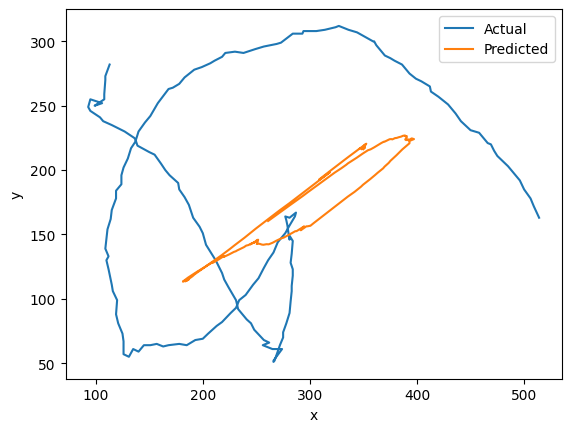

In [207]:
# code here
#using model_3 as it has the lowest rmse
#choosing time between 10 and 16 seconds

file_path = './Dataset/Testing/test01.txt'
data_test = process_data(file_path)
data_10_16 = data_test[1000:1180,:]
x_test = data_10_16[:, 0]
y_test = data_10_16[:, 1]
plt.plot(x_test, y_test, label='Actual')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
lookback = 180
predictions = []

for i in range(1600, 1780, 90):
    x = torch.tensor(data_test[i-lookback:i, :], dtype=torch.float32)
    output = model(x)
    output = output[:90]
    predictions.append(output.detach().numpy())

x_pred = np.array(predictions)[:, :, 0].flatten()
y_pred = np.array(predictions)[:, :, 1].flatten()
plt.plot(x_pred, y_pred, label='Predicted')
plt.legend()
plt.show()





### Discussion

* How does changing the number of layers and neurons affect the error? Try out 3-4 reasonable combinations of these hyperparameters (i.e. evenly spaced enough to show some appreciable difference etc).

Starting with a 1 layer and few(50) neurons, there tends to be higher error due to limited capacity for capturing complex patterns. Increasing the number of neurons(128) in a single layer often leads to decreased error as the network gains more capability to learn intricate relationships in the data. Introducing multiple layers(3 layers added) with few neurons(50) can further reduce error by enhancing the model's capacity. The error is even further reduced when more neurons(128) are used in each of the 3 layers, though there's a risk of overfitting. Conversely, employing decreasing neurons across layers presents a trade-off between complexity and generalization, potentially resulting in fluctuating error rates depending on the dataset and architecture.

### Double click to $\color{green}{\text{add explanation/reasoning here}}$

# **Part 3B (Bonus Part): Mapping the Predicted Path onto the Video [5 marks]**

* Select the best-performing NN model from the ones you implemented above. Overlay the actual and predicted paths on the video frame. Sample is provided below.
* OpenCV documentation might be helpful for this task!

<video width="620" height="440" controls>
  <source src="./bonus_sample.mp4" type="video/mp4">
</video>

In [ ]:
# code here